In [1]:
import numpy as np

from scipy.linalg import block_diag

import matplotlib.pyplot as plt
import umap
from sklearn.cluster import DBSCAN

import argparse
import numpy
import torch

from datasets import load_dataloaders, load_mnist
from model.hopfield.network import DeepHopfieldEnergy
from model.function.network import Network
from model.function.cost import SquaredError
from model.hopfield.minimizer import FixedPointMinimizer
from training.sgd import EquilibriumProp, Backprop, AugmentedFunction
from training.epoch import Trainer, Evaluator
from training.monitor import Monitor, Optimizer

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons

In [2]:
batch_size = 32
dataset = 'TwoMoons'
training_loader, test_loader = load_dataloaders(dataset, batch_size, augment_32x32=False, normalize=False)

num_hidden_layers = 1
num_neurons = 64
model = 'dhn-'+str(num_hidden_layers)+'h_twomoons'
layer_shapes = []
layer_shapes.append((2,))
for i in range(num_hidden_layers):
    layer_shapes.append((num_neurons,))

num_iterations_inference = 50
num_iterations_training = 20
nudging = 0.2
num_epochs = 20

weight_init_dist = 'xavier_uniform'
weight_gains = [1.0] * (num_hidden_layers+1)
learning_rates_weights = list(np.linspace(0.2, 0.01, num_hidden_layers+1))
learning_rates_biases = list(np.linspace(0.2, 0.01, num_hidden_layers+1))

energy_fn = DeepHopfieldEnergy(layer_shapes, weight_gains, weight_init_dist)
if torch.cuda.is_available(): device = "cuda"
else: device = "cpu"
energy_fn.set_device(device)

output_layer = energy_fn.layers()[-1]
cost_fn = SquaredError(output_layer)
network = Network(energy_fn)

params = energy_fn.params()
layers = energy_fn.layers()
free_layers = network.free_layers()

augmented_fn = AugmentedFunction(energy_fn, cost_fn)
energy_minimizer_training = FixedPointMinimizer(augmented_fn, free_layers)
estimator = EquilibriumProp(params, layers, augmented_fn, cost_fn, energy_minimizer_training)
estimator.nudging = nudging
estimator.variant = 'centered'

energy_minimizer_training.num_iterations = num_iterations_training
energy_minimizer_training.mode = 'asynchronous'

learning_rates = learning_rates_biases + learning_rates_weights
momentum = 0.
weight_decay = 0. * 1e-4
optimizer = Optimizer(energy_fn, cost_fn, learning_rates, momentum, weight_decay)

energy_minimizer_inference = FixedPointMinimizer(energy_fn, free_layers)
energy_minimizer_inference.num_iterations = num_iterations_inference
energy_minimizer_inference.mode = 'asynchronous'

trainer = Trainer(network, cost_fn, params, training_loader, estimator, optimizer, energy_minimizer_inference)
evaluator = Evaluator(network, cost_fn, test_loader, energy_minimizer_inference)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)
path = '/'.join(['papers/fast-drn', model, 'EP'])
monitor = Monitor(energy_fn, cost_fn, trainer, scheduler, evaluator, path)


In [1]:
def hidden_hopfield_energy(w, n, b, activation):
    interaction_term = np.einsum('ijk,jik->jk', activation(np.transpose(n[1:, :, :], (1, 0, 2))), w @ activation(n[:-1, :, :]))
    norm_term = 0.5*np.sum(np.square(n))
    bias_term = np.einsum('ijk, ijk -> ik', b, activation(n))

    return norm_term - np.sum(interaction_term) - np.sum(bias_term)

def hidden_hopfield_grad(w, n, b, activation, activation_derivative):
    act_n = activation(n[:, :, 0])  # Shape (num_layers, num_neurons)
    act_deriv_n = activation_derivative(n[:, :, 0])  # Shape (num_layers, num_neurons
    grad = np.zeros_like(n)
    grad[:, :, 0] = n[:, :, 0] - (act_deriv_n[:, :] * b[:, :, 0])
    pre_term = np.einsum('bji,bj->bi', w[:, :, :], act_n[:-1, :])
    post_term = np.einsum('bij,bj->bi', w[:, :, :], act_n[1:, :])
    grad[1:, :, 0] -= activation_derivative(n[1:, :, 0]) * pre_term
    grad[:-1, :, 0] -= activation_derivative(n[:-1, :, 0]) * post_term

    return grad

def interaction_energy(pre_n, post_n, w, pre_b, activation):
    int_term = activation(pre_n).T @ w @ activation(post_n)
    b_term = pre_b.T @ activation(pre_n)
    norm_term = 0.5*np.sum(np.square(pre_n))

    return norm_term - int_term - b_term

def interaction_grad(pre_n, post_n, w, pre_b, activation, activation_derivative, freeze_pre = False):

    post_grad = -1.0*activation_derivative(post_n).T * (w.T @ activation(pre_n)) 

    if freeze_pre:
        pre_grad = np.zeros_like(pre_n)
    else:
        pre_grad = pre_n - (1.0*activation_derivative(pre_n).T  * (w @ activation(post_n) + pre_b))

    return pre_grad, post_grad



class ModelBuilder():

    def __init__(self, internal_w, internal_b, activation, input_specs, output_specs) -> None:
        self.w_h = internal_w
        self.b_h = internal_b
        self.activation = activation

        self.input_layer = input_specs
        self.output_layer = output_specs

    def 






class InferenceMachine():

    def __init__(self, w, b, activation) -> None:
        self.w = w
        self.b = b
        self.activation = activation

    def generalized_infernece()

SyntaxError: incomplete input (243175687.py, line 25)

In [3]:
def random_symmetric_matrix(N, mu, sigma):
    M = np.random.lognormal(mean=mu, sigma=sigma, size=(N, N))
    signs = np.random.choice([-1, 1], size=(N, N))
    M *= signs
    return M

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_prime(x):
    return np.exp(x) / ((1 + np.exp(x))**2)

def block_diagonal_matrix(matrices):
    return block_diag(*matrices)

def get_diagonal_blocks(matrix, L):
    N = np.shape(matrix)[0]
    block_size = N // L
    diagonal_blocks = []

    for i in range(L): 
        row_start = i * block_size
        row_end = row_start + block_size
        col_start = i * block_size
        col_end = col_start + block_size

        diagonal_block = matrix[row_start:row_end, col_start:col_end]
        diagonal_blocks.append(diagonal_block)

    return diagonal_blocks

def split_array(arr, L):
    n_p_layer = int(np.shape(arr)[0] / L)
    return [arr[i:i + n_p_layer] for i in range(0, len(arr), n_p_layer)]



In [5]:
def hopfield_energy(w, n, b, activation):
    interaction_term = np.einsum('ijk,jik->jk', activation(np.transpose(n[1:, :, :], (1, 0, 2))), w @ activation(n[:-1, :, :]))
    norm_term = 0.5*np.sum(np.square(n))
    bias_term = np.einsum('ijk, ijk -> ik', b, activation(n))

    return norm_term - np.sum(interaction_term) - np.sum(bias_term)


def true_hopfield_grad(w, n, b, activation, activation_derivative):

    grad = np.zeros(np.shape(n))

    for i in range(1, (np.shape(n)[0])-1):
        
        for j in range(np.shape(n)[1]):
            
            temp = n[i, j, 0] - (activation_derivative(n[i, j, 0])*b[i,j,0])
            
            for k in range(np.shape(n)[1]):

                pre_term = w[i-1,k,j] * activation(n[i-1, k, 0])
                post_term = w[i,j,k] * activation(n[i+1, k, 0])
                            
                temp -= activation_derivative(n[i, j, 0]) * pre_term
                temp -= activation_derivative(n[i, j, 0]) * post_term

            grad[i, j, 0] = temp

    for m in range(np.shape(n)[1]):

        grad[0, m, 0] = n[0, m, 0] - (activation_derivative(n[0, m, 0])*b[0,m,0])
        grad[-1, m, 0] = n[-1, m, 0] - (activation_derivative(n[-1, m, 0])*b[-1,m,0])

        for l in range(np.shape(n)[1]):

            grad[0, m, 0] -= activation_derivative(n[0, m, 0])*(w[0,m,l] * activation(n[1, l, 0])) 
            grad[-1, m, 0] -= activation_derivative(n[-1, m, 0])*(w[-1,l,m] * activation(n[-2, l, 0]))
    
    return grad


def hopfield_grad(w, n, b, activation, activation_derivative):

    act_n = activation(n[:, :, 0])  # Shape (num_layers, num_neurons)
    act_deriv_n = activation_derivative(n[:, :, 0])  # Shape (num_layers, num_neurons)

    grad = np.zeros_like(n)

    # Compute gradient for interior layers (excluding first & last)
    grad[:, :, 0] = n[:, :, 0] - (act_deriv_n[:, :] * b[:, :, 0])

    pre_term = np.einsum('bji,bj->bi', w[:, :, :], act_n[:-1, :])
    post_term = np.einsum('bij,bj->bi', w[:, :, :], act_n[1:, :])

    grad[1:, :, 0] -= activation_derivative(n[1:, :, 0]) * pre_term
    grad[:-1, :, 0] -= activation_derivative(n[:-1, :, 0]) * post_term

    return grad
    
    

In [16]:
n_per_Layer = 2
n_layers = 1

weights = np.random.lognormal(0.1, 1.0, (n_layers - 1, n_per_Layer, n_per_Layer))
sign_flip = np.random.choice([1, -1], size=weights.shape)
weights = weights * sign_flip

bias = np.random.lognormal(0.1, 1.0, (n_layers, n_per_Layer, 1))
sign_flip2 = np.random.choice([1, -1], size=bias.shape)
bias = bias * sign_flip2

initial_state = np.random.uniform(-2.0, 2.0, (n_layers, n_per_Layer, 1))


def hop_grad_fn(n):
    return hopfield_grad(weights, n, bias, sigmoid, sigmoid_prime)

def hopfield_energy_fn(n):

    return hopfield_energy(weights, n, bias, sigmoid)

In [17]:
def hamiltonian_grad_fn(n):
    # Use the hopfield_grad_fn to compute the gradient (potential energy gradient)
    return hop_grad_fn(n)

def hamiltonian_monte_carlo(initial_state, num_steps, var, step_size=0.1, num_leapfrog_steps=10):
    state = initial_state
    samples = []
    energy = []

    for i in range(num_steps):
        # 1. Sample momentum from a Gaussian distribution
        momentum = np.random.normal(0, var, size=state.shape)
        
        # 2. Compute the initial energy (potential + kinetic)
        initial_state_energy = hopfield_energy_fn(state)  # Energy from the gradient
        initial_momentum_energy = 0.5 * np.sum(np.einsum('ijk,ijk->ij', momentum, momentum))  # Kinetic energy
        
        # 3. Perform leapfrog integration
        state_new = state.copy()
        momentum_new = momentum.copy()

        # Leapfrog integration
        for _ in range(num_leapfrog_steps):
            # Half step for momentum
            momentum_new -= 0.5 * step_size * hamiltonian_grad_fn(state_new)
            # Full step for state
            state_new += step_size * momentum_new
            # Half step for momentum
            momentum_new -= 0.5 * step_size * hamiltonian_grad_fn(state_new)

        # 4. Compute the new energy (potential + kinetic)
        final_state_energy = hopfield_energy_fn(state_new)
        final_momentum_energy = 0.5 * np.sum(np.einsum('ijk,ijk->ij', momentum_new, momentum_new))

        # 5. Metropolis acceptance step
        energy_diff = (final_state_energy + final_momentum_energy) - (initial_state_energy + initial_momentum_energy)
        acceptance_prob = np.exp(-energy_diff)

        if np.random.rand() < acceptance_prob:
            # Accept the new state
            state = state_new
        
        samples.append(state)
        energy.append(hopfield_energy_fn(state))
        
        if i % 1000 == 0:
            print(i)
    
    return np.array(samples), np.array(energy)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000


/Users/collinszczepanski/Code/cris/eqprop/chenv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/collinszczepanski/Code/cris/eqprop/chenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'Equilibrium Energy')

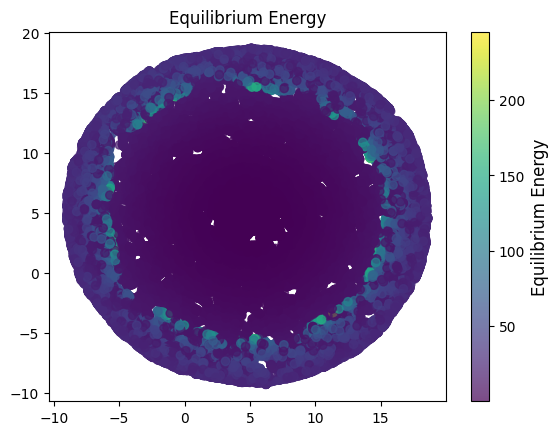

In [18]:
initial_state = np.random.uniform(-5.0, 5.0, (n_layers, n_per_Layer, 1))
num_steps = 50000
samples = hamiltonian_monte_carlo(initial_state, num_steps, var=5)

samp, energies = samples

umap_model1 = umap.UMAP(n_components=2, random_state=42)
umap1 = umap_model1.fit_transform(samp.squeeze(axis=-1).reshape(np.shape(samp)[0], -1))

fig, ax = plt.subplots()

sc1 = ax.scatter(umap1[:, 0], umap1[:, 1], c=energies, cmap='viridis', alpha=0.7)
cbar1 = fig.colorbar(sc1, ax=ax)
cbar1.set_label("Equilibrium Energy", fontsize=12)
ax.set_title('Equilibrium Energy')

/var/folders/rd/1y9c6n950yb5v2f09rhg0zv00000gn/T/ipykernel_20299/2992524354.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))  # Use tab10 colormap


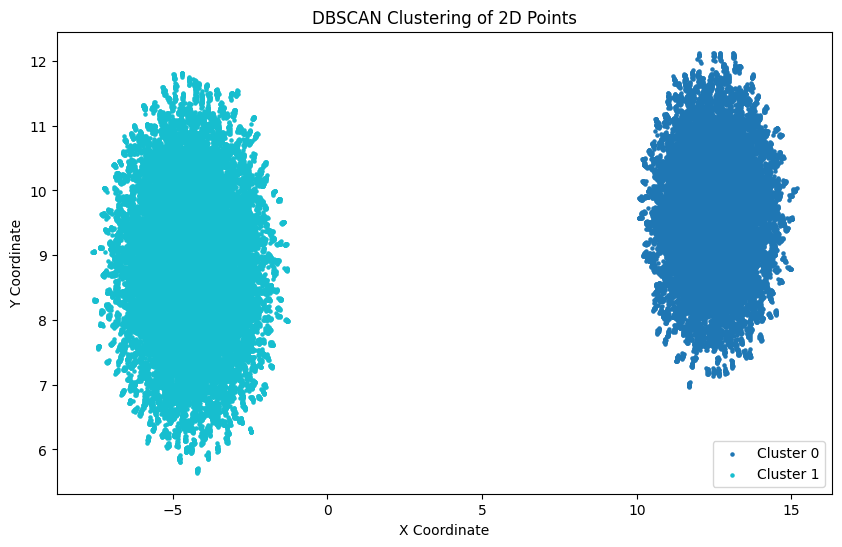

In [10]:
points = umap1

dbscan = DBSCAN(eps=0.5, min_samples=10)
labels = dbscan.fit_predict(points)

# Plot results
plt.figure(figsize=(10, 6))
unique_labels = set(labels)

# Generate colors
colors = plt.cm.get_cmap("tab10", len(unique_labels))  # Use tab10 colormap

for label in unique_labels:
    cluster_points = points[labels == label]  # Get points belonging to this cluster
    color = 'k' if label == -1 else colors(label)  # Black for noise (-1)
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=5, c=[color], label=f"Cluster {label}" if label != -1 else "Noise")

plt.title("DBSCAN Clustering of 2D Points")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

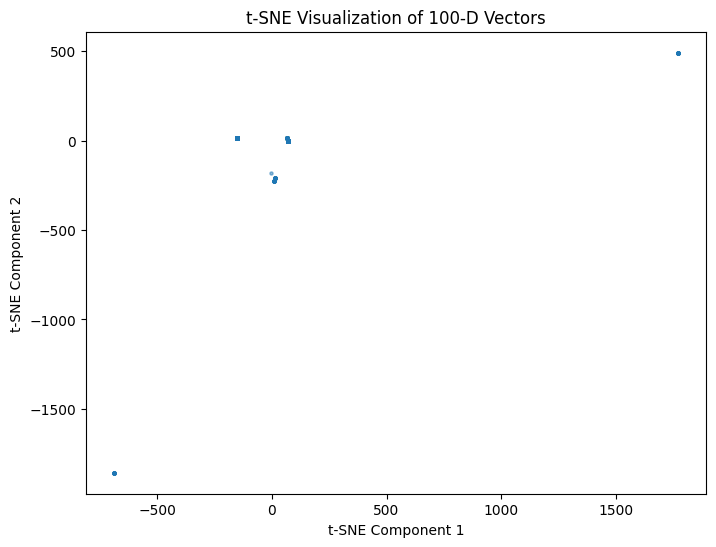

In [23]:

from sklearn.manifold import TSNE


np.random.seed(42)
data = samp.squeeze(axis=-1).reshape(np.shape(samp)[0], -1)

# Apply t-SNE (2D reduction)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
data_2d = tsne.fit_transform(data)

# Scatter plot of the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=5, alpha=0.5)  # Small markers for better visibility
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of 100-D Vectors")
plt.show()


(50000, 2)

(array([1.2000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.2000e+01,
        2.0000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 4.9937e+04,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.9000e+01]),
 array([-1856.78601074, -1809.83789062, -1762.88977051, -1715.94165039,
        -1668.99353027, -1622.04541016, -1575.09716797, -1528.14904785,
        -1481.20092773, -1434.25280762, -1387.3046875 , -1340.35656738,
        -1293.40844727, -1246.46032715, -1199.51220703, -1152.56396484,
        -1105.6159668 , -1058.

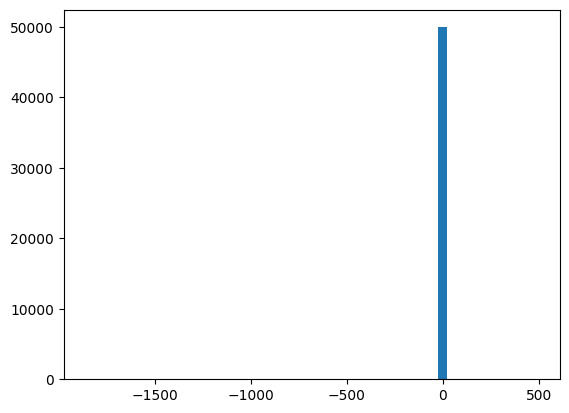

In [31]:
plt.hist(data_2d[:, 1],bins=50)

In [21]:
for i in range(len(labels)):
    if labels[i] == 0 and labels[i+1] ==1:
        before = samp[i,:,:,0].flatten()
        after = samp[i+1,:,:,0].flatten()

print(np.linalg.norm(before - after))
print(np.linalg.norm(before - samp[0,:,:,0].flatten()))

13.16381673526242
46.645308239719704


In [173]:
def input_output_energy(x, y, internal_energy, w, b, n, activation, in_w, in_b, out_w, out_b):
    int_energy = internal_energy(w, n, b, activation)
    input_interaction = 0.5 * (x.T @ x) - in_b.T @ activation(x) - activation(n[1,:,0]).T @ in_w[:,:] @ activation(x)
    output_interaction = 0.5 * (y.T @ y) - out_b.T @ activation(y) - activation(y).T @ out_w[:,:] @ activation(n[-1,:,0])

    return int_energy + input_interaction + output_interaction


In [202]:
n_per_Layer = 16
n_layers = 8

weights = np.random.lognormal(0.1, 1.0, (n_layers - 1, n_per_Layer, n_per_Layer))
sign_flip = np.random.choice([1, -1], size=weights.shape)
weights = weights * sign_flip

bias = np.random.lognormal(0.1, 1.0, (n_layers, n_per_Layer, 1))
sign_flip2 = np.random.choice([1, -1], size=bias.shape)
bias = bias * sign_flip2

initial_state = np.random.uniform(-2.0, 2.0, (n_layers, n_per_Layer, 1))


num_classes = 2
dim_data = 2

in_weights = np.random.lognormal(0.1, 1.0, (n_per_Layer, dim_data))
sign_flip = np.random.choice([1, -1], size=in_weights.shape)
in_weights = in_weights * sign_flip

in_bias = np.random.lognormal(0.1, 1.0, (dim_data, 1))
sign_flip2 = np.random.choice([1, -1], size=in_bias.shape)
in_bias = in_bias * sign_flip2

out_weights = np.random.lognormal(0.1, 1.0, (num_classes, n_per_Layer))
sign_flip = np.random.choice([1, -1], size=out_weights.shape)
out_weights = out_weights * sign_flip

out_bias = np.random.lognormal(0.1, 1.0, (num_classes, 1))
sign_flip2 = np.random.choice([1, -1], size=out_bias.shape)
out_bias = out_bias * sign_flip2

initial_state = np.random.uniform(-2.0, 2.0, (n_layers, n_per_Layer, 1))
x_fix = np.random.uniform(-2.0, 2.0, (dim_data, 1))
y_fix = np.array([[1.0,1.0]]).T

def input_energy(x):
    return input_output_energy(x, y_fix, hopfield_energy, weights, bias, initial_state, sigmoid, in_weights, in_bias, out_weights, out_bias)

def output_energy(y):
    return input_output_energy(x_fix, y, hopfield_energy, weights, bias, initial_state, sigmoid, in_weights, in_bias, out_weights, out_bias)

[[1.]
 [1.]]


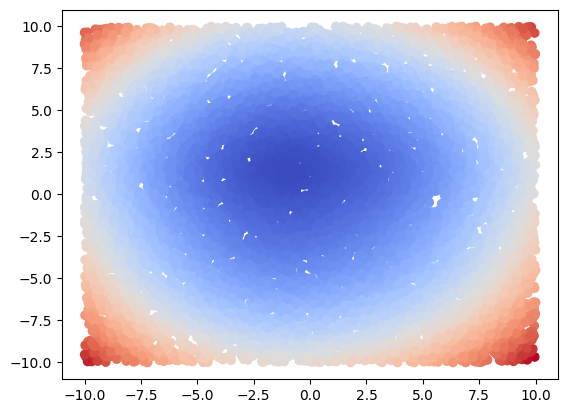

In [203]:
num_samp = 10000

energy = []
x_batch = np.random.uniform(-10.0, 10.0, (dim_data, num_samp))
print(y_fix)
for j in range(np.shape(x_batch)[-1]):
    
    energy.append(input_energy(x_batch[:,j]))

plt.scatter(x_batch[0,:], x_batch[1,:], c=energy, cmap = 'coolwarm')

/var/folders/rd/1y9c6n950yb5v2f09rhg0zv00000gn/T/ipykernel_12392/2812068079.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))  # Use tab10 colormap


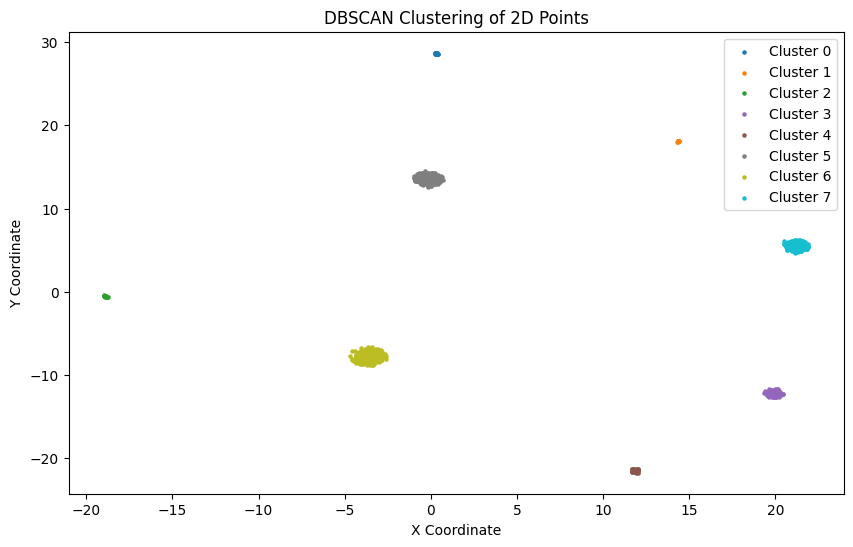

In [57]:

points = umap1

dbscan = DBSCAN(eps=0.5, min_samples=10)
labels = dbscan.fit_predict(points)

# Plot results
plt.figure(figsize=(10, 6))
unique_labels = set(labels)

# Generate colors
colors = plt.cm.get_cmap("tab10", len(unique_labels))  # Use tab10 colormap

for label in unique_labels:
    cluster_points = points[labels == label]  # Get points belonging to this cluster
    color = 'k' if label == -1 else colors(label)  # Black for noise (-1)
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=5, c=[color], label=f"Cluster {label}" if label != -1 else "Noise")

plt.title("DBSCAN Clustering of 2D Points")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()


(array([ 2.,  6.,  9., 17., 17., 27., 16., 15.,  7., 12.]),
 array([-2.88170396, -2.36958469, -1.85746543, -1.34534616, -0.83322689,
        -0.32110763,  0.19101164,  0.7031309 ,  1.21525017,  1.72736944,
         2.2394887 ]),
 <BarContainer object of 10 artists>)

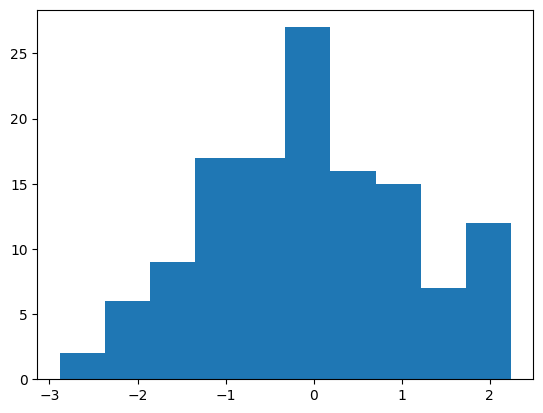

In [55]:
basin_no = 6

basin_neurons = []

flat_smap = samp.squeeze(axis=-1).reshape(np.shape(samp)[0], -1)

for i, label in enumerate(labels):
    if label == basin_no:
        basin_neurons.append(flat_smap[i, :])

basin_neurons = np.array(basin_neurons)
avg_firing = np.mean(basin_neurons, axis=0)

plt.hist(avg_firing, bins=10)

(array([239.,   0.,   0.,  59.,   0., 512.,   0.,   6.,   0.,  20., 127.,
          0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,  11.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,  24.]),
 array([-70.42687979, -67.5503208 , -64.67376181, -61.79720282,
        -58.92064383, -56.04408484, -53.16752585, -50.29096686,
        -47.41440787, -44.53784889, -41.6612899 , -38.78473091,
        -35.90817192, -33.03161293, -30.15505394, -27.27849495,
        -24.40193596, -21.52537697, -18.64881799, -15.772259  ,
        -12.89570001, -10.01914102,  -7.14258203,  -4.26602304,
         -1.38946405,   1.48709494,   4.36365393,   7.24021291,
         10.1167719 ,  12.99333089,  15.86988988,  18.74644887,
         21.62300786,  24.49956685,  27.37612584,  30.25268483,
         33.12924381,  36.0058028 ,  38.88236179,  41.75892078,
         44.635479

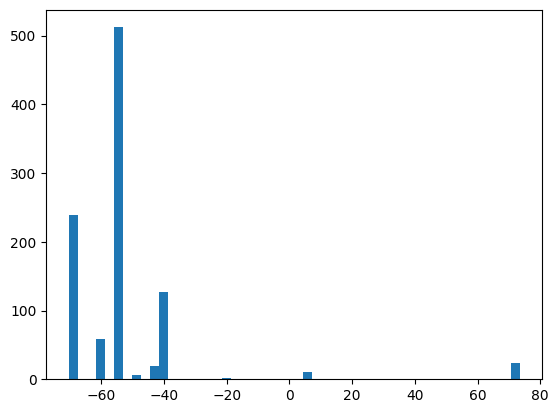

In [36]:
plt.hist(energies, bins=50)

In [ ]:
init_neurons = np.random.uniform(n_min, n_max, (n_layers, n_per_Layer, 1))

num_s = 1000
step = 1000

samp = metropolis_hastings(init_neurons, step, num_s)

In [ ]:
def sample(num)

In [ ]:
def hopfield_energy(weight, bias, neuron, num_layers):

    U = 0

    num_neurons = np.shape(neuron)[0]
    if num_neurons % num_layers != 0:
        raise ValueError('Neurons not divisible into Layers')
    else:
        weight_by_layer = get_diagonal_blocks(weight, num_layers)
        bias_by_layer = split_array(bias, num_layers)
        neuron_by_layer = split_array(neuron, num_layers)

    for i in range(len(weight_by_layer)-1):

        w = weight_by_layer[i]
        b = bias_by_layer[i]
        pre_act = sigmoid(neuron_by_layer[i])
        post_act = sigmoid(neuron_by_layer[i+1])

        U += 0.5*(neuron_by_layer[i].T @ neuron_by_layer[i])

        U -= b.T @ pre_act
        U -= pre_act.T @ w @ post_act

    U += 0.5*(neuron_by_layer[-1].T @ neuron_by_layer[-1])
    U -= b.T @ sigmoid(neuron_by_layer[-1])

    return U

def hopfield_grad(weight, bias, neuron, num_layers):

    grad = []

    weight_by_layer = get_diagonal_blocks(weight, num_layers)
    bias_by_layer = split_array(bias, num_layers)
    neuron_by_layer = split_array(neuron, num_layers)

    grad.append(sigmoid_prime(neuron_by_layer[0]) * ((sigmoid(neuron_by_layer[1]).T @ weight_by_layer[0]) - bias_by_layer[0]) - neuron_by_layer[0])

    for i in range(1, len(weight_by_layer)-1):

        grad = []

        w_to_pre = weight_by_layer[i]
        w_to_post = weight_by_layer[i+1]
        b = bias_by_layer[i]
        pre_act = sigmoid(neuron_by_layer[i-1])
        post_act = sigmoid(neuron_by_layer[i+1])

        grad.append( sigmoid_prime(neuron_by_layer[i]) * (w_to_pre @ pre_act + post_act.T @ w_to_post - b) - neuron_by_layer[i])

    grad.append(sigmoid_prime(neuron_by_layer[-1]) * (weight_by_layer[-1] @ sigmoid(neuron_by_layer[-2]).T - bias_by_layer[-1]) - neuron_by_layer[-1])

    return np.concatenate(grad)


In [ ]:

n_per_layer = 5
ln_mu = 0.1
ln_scale = 1.0

num_layers = 2

matrices = []
for i in range(num_layers-1):
    matrices.append(random_symmetric_matrix(n_per_layer, ln_mu, ln_scale))

a, b = 0, 1 

bias = np.random.uniform(a, b, n_per_layer)
weights = block_diagonal_matrix(matrices)


def hopfield_grad_fn(n):

    return hopfield_grad(weights, bias, n, num_layers)

In [ ]:
time_step = 1e-1
samples = []
energy_plot = []

num_steps = 1000
num_samples = 10000


for j in range(num_samples):
    state = np.random.uniform(a, b, num_neurons)
    curr = np.array([state[i] for i in range(len(state))])
    


    for i in range(num_steps):
        grad = -1.0*hopfield_grad(weights, bias, curr, num_layers)
        noise = np.random.normal(loc=0, scale=0.1, size=len(grad))

        curr = curr - time_step * grad + noise
        
    samples.append(curr)
    energy_plot.append(hopfield_energy(weights, bias, curr, num_layers))
    if j % 100 == 0 :
        print(j/100)


samples = np.array(samples)

print(np.shape(samples))


In [ ]:
import umap

umap= umap.UMAP(n_components=2, random_state=42)
emb = umap.fit_transform(samples)

fig, ax = plt.subplots()
sc1 = ax.scatter(emb[:, 0], emb[:, 1], c=energy_plot, cmap='coolwarm', alpha=0.7)
cbar1 = fig.colorbar(sc1, ax=ax)
cbar1.set_label("Equilibrium Energy", fontsize=12)
ax.set_title('Equilibrium Energy')


In [ ]:
print(np.max(energy_plot)-np.min(energy_plot))

# Ignore

In [ ]:
def hopfield_energy(weight, bias, neuron, num_layers):

    U = 0

    num_neurons = np.shape(neuron)[0]
    if num_neurons % num_layers != 0:
        raise ValueError('Neurons not divisible into Layers')
    else:
        weight_by_layer = get_diagonal_blocks(weight, num_layers)
        bias_by_layer = split_array(bias, num_layers)
        neuron_by_layer = split_array(neuron, num_layers)

    for i in range(len(weight_by_layer)-1):

        w = weight_by_layer[i]
        b = bias_by_layer[i]
        pre_act = sigmoid(neuron_by_layer[i])
        post_act = sigmoid(neuron_by_layer[i+1])

        U += 0.5*(neuron_by_layer[i].T @ neuron_by_layer[i])
        U -= b.T @ pre_act
        U -= pre_act.T @ w @ post_act

    U += 0.5*(neuron_by_layer[-1].T @ neuron_by_layer[-1])
    U -= b.T @ sigmoid(neuron_by_layer[-1])

    return U

def hopfield_grad(weight, bias, neuron, num_layers):

    grad = []

    weight_by_layer = get_diagonal_blocks(weight, num_layers)
    bias_by_layer = split_array(bias, num_layers)
    neuron_by_layer = split_array(neuron, num_layers)

    grad.append(sigmoid_prime(neuron_by_layer[0]) * (sigmoid(neuron_by_layer[1]).T @ weight_by_layer[1] - bias_by_layer[0]) - neuron_by_layer[0])

    for i in range(1, len(weight_by_layer)-1):

        grad = []

        w_to_pre = weight_by_layer[i]
        w_to_post = weight_by_layer[i+1]
        b = bias_by_layer[i]
        pre_act = sigmoid(neuron_by_layer[i-1])
        post_act = sigmoid(neuron_by_layer[i+1])

        grad.append( sigmoid_prime(neuron_by_layer[i]) * (w_to_pre @ pre_act + post_act.T @ w_to_post - b) - neuron_by_layer[i])

    grad.append( sigmoid_prime(neuron_by_layer[-1]) * (weight_by_layer[-1] @ sigmoid(neuron_by_layer[-2]).T - bias_by_layer[-1]) - neuron_by_layer[-1])

    return np.concatenate(grad)



In [ ]:
neurons[0]

In [ ]:
step_size = 0.01
beta = 1.0
n_steps = 100

samples = []
current_state = neurons


for _ in range(n_steps):

    grad_energy = hopfield_grad(weights, bias, current_state, num_layers)    
    noise = np.sqrt(2 * step_size * beta**-1) * np.random.randn(*current_state.shape)
    current_state -= step_size * grad_energy + noise
    samples.append(current_state)

print(samples)


In [ ]:
n_steps = 100
step = 0.05

langevin_dynamics(hopfield_grad, n_steps, neurons, weights, bias, num_layers, step_size=0.1, beta=0.01)